## SHARED — Data Loading and Preparation

In [47]:
# Import all libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

print("All libraries imported successfully!")

All libraries imported successfully!


In [48]:
# Load the dataset
df = pd.read_csv('/Users/mamatajoshi/Desktop/HCI/eda/Preprocessed_Covid19.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset loaded successfully!
Shape: (100000, 20)
Columns: ['USMER', 'MEDICAL_UNIT', 'SEX', 'PATIENT_TYPE', 'DATE_DIED', 'INTUBED', 'PNEUMONIA', 'AGE', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'ICU']


In [49]:
# Create target column — DIED
# If DATE_DIED is '9999-99-99' it means the patient SURVIVED = 0
# If DATE_DIED has a real date it means the patient DIED = 1

df['DIED'] = df['DATE_DIED'].apply(lambda x: 0 if x == '9999-99-99' else 1)

print(f"Target column created!")
print(f"Survived (0): {(df['DIED'] == 0).sum()}")
print(f"Died (1): {(df['DIED'] == 1).sum()}")

Target column created!
Survived (0): 58593
Died (1): 41407


In [50]:
# Select features (inputs) and target (output)
features = ['AGE', 'SEX', 'DIABETES', 'PNEUMONIA', 'HIPERTENSION', 
            'OBESITY', 'CARDIOVASCULAR', 'RENAL_CHRONIC', 'ASTHMA', 
            'TOBACCO', 'COPD', 'INMSUPR', 'OTHER_DISEASE', 'INTUBED', 'ICU']

X = df[features]  # inputs
y = df['DIED']    # output

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("Features selected successfully!")

Features shape: (100000, 15)
Target shape: (100000,)
Features selected successfully!


In [51]:
# Fill missing values
X = X.fillna(X.median())
print("Missing values handled!")
print(f"Any NaN left: {X.isnull().sum().sum()}")

Missing values handled!
Any NaN left: 0


In [52]:
# Split data into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print("Data split successfully!")

Training set size: (80000, 15)
Testing set size: (20000, 15)
Data split successfully!


## MAMATA'S MODEL — Logistic Regression

In [53]:
# Train Logistic Regression model
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Training Logistic Regression...
Logistic Regression trained successfully!


In [54]:
# Evaluate Logistic Regression
lr_pred = lr_model.predict(X_test)

print("=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall:    {recall_score(y_test, lr_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr_pred):.4f}")

=== LOGISTIC REGRESSION RESULTS ===
Accuracy:  0.8344
Precision: 0.8283
Recall:    0.7591
F1 Score:  0.7922



Visualization saved as 'mamata_logistic_regression_results.png' ✅


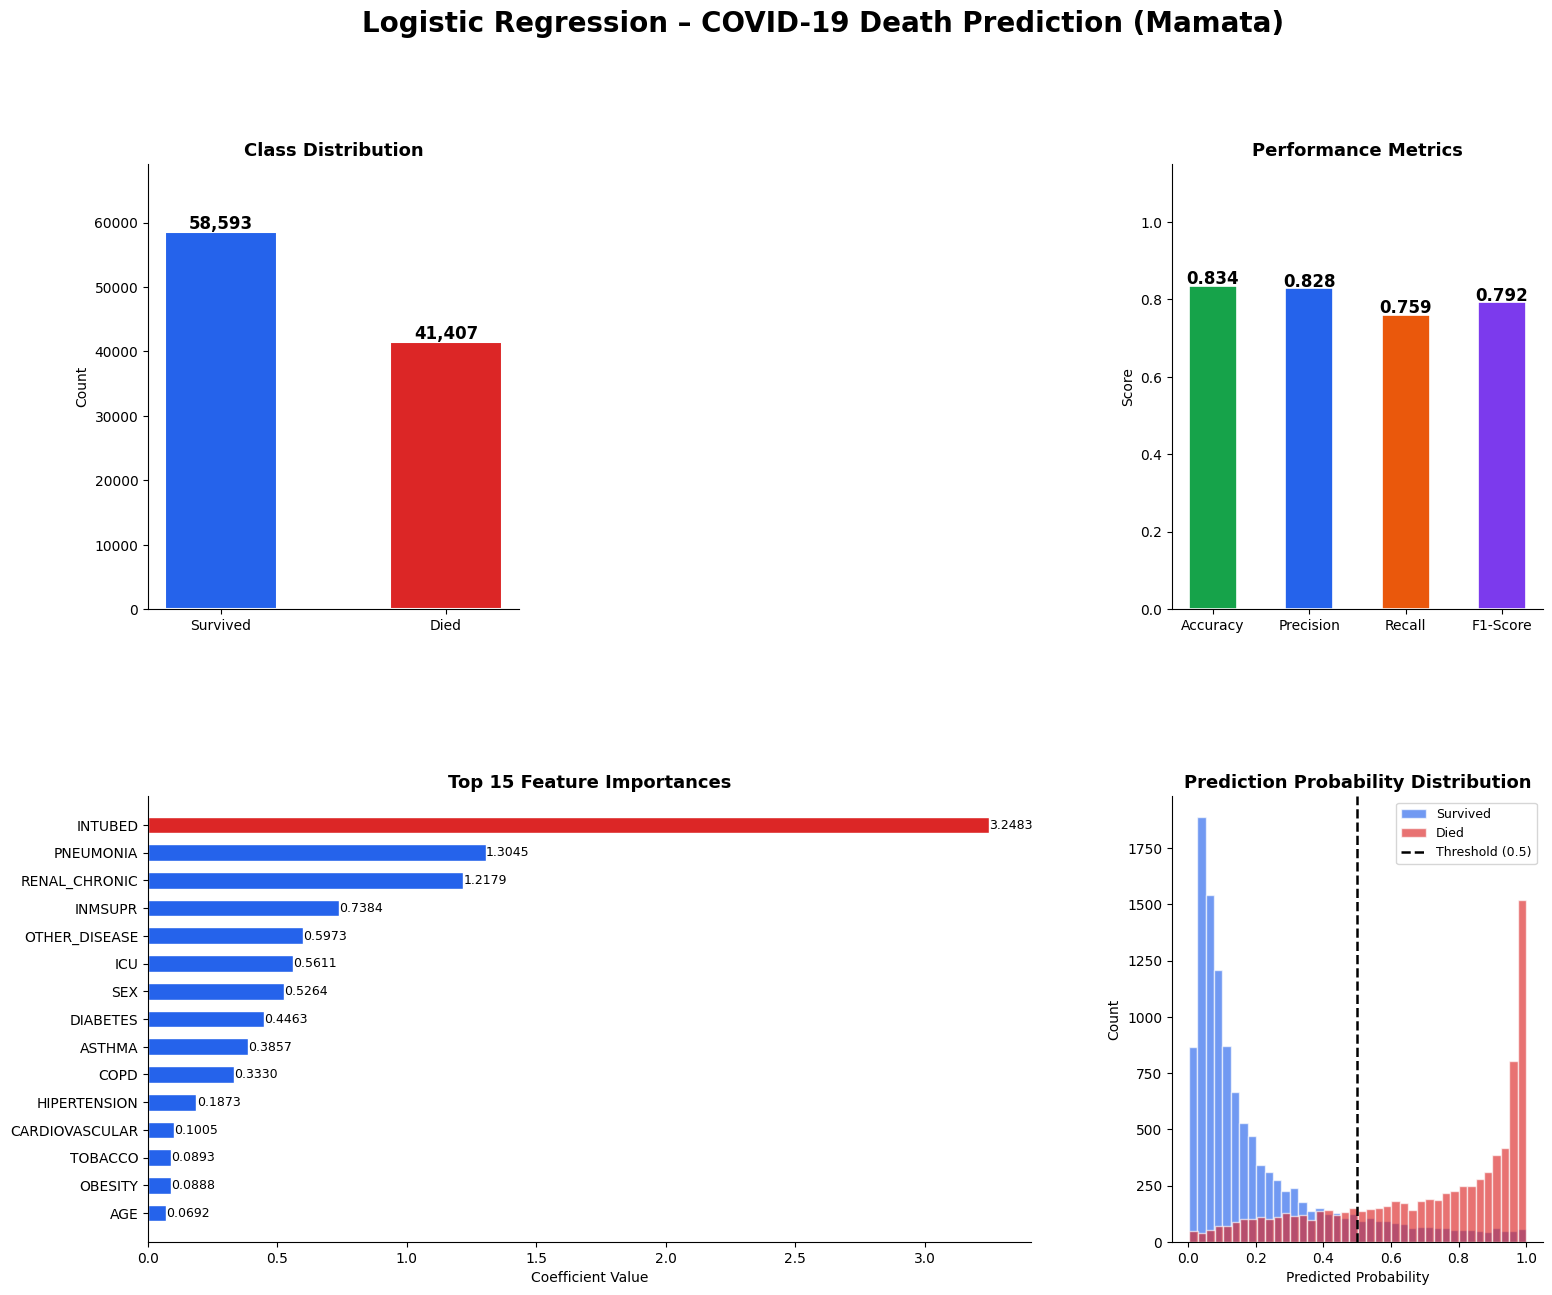

In [55]:
import matplotlib.gridspec as gridspec
plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.facecolor'  : 'white'
})
BLUE, RED, GREEN, ORANGE, PURPLE = '#2563EB', '#DC2626', '#16A34A', '#EA580C', '#7C3AED'

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Logistic Regression – COVID-19 Death Prediction (Mamata)',
             fontsize=20, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# Plot 1: Class Distribution
ax1 = fig.add_subplot(gs[0, 0])
counts = y.value_counts()
bars1  = ax1.bar(['Survived', 'Died'], counts.values,
                 color=[BLUE, RED], edgecolor='white', linewidth=1.5, width=0.5)
for b in bars1:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 500,
             f'{b.get_height():,}', ha='center', fontweight='bold', fontsize=12)
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_ylim(0, max(counts.values) * 1.18)

# Plot 2: Performance Metrics Bar
ax3 = fig.add_subplot(gs[0, 2])
metrics = {
    'Accuracy' : accuracy_score(y_test, lr_pred),
    'Precision': precision_score(y_test, lr_pred),
    'Recall'   : recall_score(y_test, lr_pred),
    'F1-Score' : f1_score(y_test, lr_pred)
}
b3 = ax3.bar(list(metrics.keys()), list(metrics.values()),
             color=[GREEN, BLUE, ORANGE, PURPLE],
             edgecolor='white', linewidth=1.2, width=0.5)
for b in b3:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{b.get_height():.3f}', ha='center', fontsize=12, fontweight='bold')
ax3.set_title('Performance Metrics', fontsize=13, fontweight='bold')
ax3.set_ylim(0, 1.15)
ax3.set_ylabel('Score')

# Plot 3: Feature Importances (using coefficients for Logistic Regression)
ax4 = fig.add_subplot(gs[1, :2])
fi = pd.Series(abs(lr_model.coef_[0]), index=features).sort_values(ascending=False)
top15      = fi.head(15)
bar_colors = [RED if i == 0 else BLUE for i in range(len(top15))]
bars4      = ax4.barh(top15.index[::-1], top15.values[::-1],
                      color=bar_colors[::-1], edgecolor='white', height=0.6)
for b in bars4:
    ax4.text(b.get_width() + 0.001, b.get_y() + b.get_height()/2,
             f'{b.get_width():.4f}', va='center', fontsize=9)
ax4.set_title('Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax4.set_xlabel('Coefficient Value')

# Plot 4: Prediction Probability Distribution
ax5 = fig.add_subplot(gs[1, 2])
y_proba = lr_model.predict_proba(X_test)[:, 1]
ax5.hist(y_proba[y_test == 0], bins=40, alpha=0.65, color=BLUE,
         label='Survived', edgecolor='white')
ax5.hist(y_proba[y_test == 1], bins=40, alpha=0.65, color=RED,
         label='Died', edgecolor='white')
ax5.axvline(0.5, color='black', linestyle='--', lw=1.8, label='Threshold (0.5)')
ax5.set_xlabel('Predicted Probability')
ax5.set_ylabel('Count')
ax5.legend(fontsize=9)
ax5.set_title('Prediction Probability Distribution', fontsize=13, fontweight='bold')

plt.savefig('mamata_logistic_regression_results.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print("\nVisualization saved as 'mamata_logistic_regression_results.png' ✅")